# VDP Sensitivity Analysis
## AMATH 445 Final Project — Omar Rahman

Sensitivity analysis of the Mozaffaripour et al. (2025) 129Xe MRI VDP pipeline. Varies clustering algorithm, number of clusters k, and trachea masking strategy on a single patient scan (Experiments 1–5), then extends the core findings to a 10-patient cohort (Experiment 6). MCID = 2%.

## 1. Introduction

- ¹²⁹Xe MRI maps pulmonary ventilation; VDP = fraction of in-mask voxels in the lowest-intensity cluster
- MCID = 2% (McIntosh et al. 2023) — pipeline-induced shifts ≥ 2% can mimic real clinical change
- Source pipeline: Mozaffaripour et al. (2025), hierarchical complete linkage, k = 5, trachea excluded
- Goal: characterize how sensitive VDP is to algorithm choice, k, and masking; benchmark supervised baselines

> [1] Mozaffaripour et al., *Acad Radiol* 32(3), 2025.  
> [2] McIntosh et al., *Acad Radiol* 30(12), 2023.  
> [3] Y. Lee., *Carolina Digital Repository*, 2020. https://cdr.lib.unc.edu/concern/data_sets/m900p0761


## 2. Background

Hierarchical clustering — builds dendrogram by iteratively merging closest clusters
- *Complete linkage*: inter-cluster distance = max pairwise distance (O(n²), must subsample)
- *Ward linkage*: merges pair with smallest increase in within-cluster variance

K-Means — hard partition, minimizes within-cluster sum of squares; fits on all voxels

GMM — soft clustering via EM; models intensity histogram as k Gaussians, assigns voxel to max-posterior component

Supervised baselines — logistic regression and tiny MLP (4 → 16 → 1) trained on voxel-level GT defect labels  
Features: normalized intensity + spatial coords (x, y, z); 5-fold stratified CV


## 3. Data

### 3.1 Single-Patient Dataset

- Volume: 128×128×16, uint8 intensities [0, 255]
- Trachea-excluded mask (`HeMaskNoTrachea`): 35,349 voxels — primary analysis mask
- Trachea-included mask: 51,733 voxels
- GT cluster labels: `HeClusteringResult.mat` (5 classes, cluster 1 = defect)
- GT VDP = 31.06%

### 3.2 Multi-Patient Cohort

- 10 patients: `2569-005` → `2569-015` (excl. 014) from `High_res_Xe/data/`
- `{pid}_XE.mat` → `FUNC` (int16 Xe scan, normalized to [0,255])
- `{pid}_ROI.mat` → `ANATOM_ROI` (uint8 lung mask)
  - Patients 005/006/007: ROI at 4× resolution (512×640) → 4×4 block max-pool to match scan
  - Patients 008–015: ROI already at scan resolution (128×160)
- GT VDP per patient: `High_res_Xe/outputs/VentMaps/VDPinfo.mat` → `VDP_Xe` field

**Dataset comparison**

| Property | Single-patient (Exp 1–5) | 10-patient cohort (Exp 6) |
|---|---|---|
| Scan dimensions | 128×128×16 | 128×160×18 (mostly) |
| Intensity dtype | uint8 [0, 255] | int16, normalized |
| Lung mask | Trachea-excluded | ROI only, no trachea separation |
| GT type | Voxel-level 5-class labels | Patient-level scalar VDP |
| Trachea mask | Available | Not available |

**Limitation:** no trachea masks or voxel labels in cohort → Exp 2, 4, 5 cannot transfer


## 4. Methods

### 4.1 VDP Estimator

$$\text{VDP} = \frac{|\{v \in \mathcal{M} : \hat{c}_v = \arg\min_j \bar{I}_j\}|}{|\mathcal{M}|} \times 100\%$$

- $\hat{c}_v$ = predicted cluster, $\bar{I}_j$ = mean intensity of cluster j
- Lowest-intensity cluster → defect; same definition as published pipeline
- 4 algorithms: Hierarchical Complete, Hierarchical Ward, K-Means, GMM (all via `compute_vdp()`)
- Hierarchical methods: 4,000-voxel subsample to build dendrogram; remaining voxels → nearest centroid

### 4.2 Supervised Baselines

- Features: $[I_v/255,\ r/(R-1),\ c/(C-1),\ s/(S-1)]$ (4 features, min-max normalized)
- LR: sklearn LogisticRegression; MLP: 4 → 16 → 1, ReLU, sigmoid output
- 5-fold stratified CV; VDP = fraction of in-mask voxels predicted defect
- Single-patient only (requires voxel-level GT labels)

### 4.3 Bootstrap Confidence Intervals

- Sample with replacement from in-mask voxels; n = 500 (single patient), n = 200 (per cohort patient)
- Recompute VDP at k = 5 for all 4 methods per sample
- 95% CI = [2.5th, 97.5th] percentile of bootstrap distribution


In [ ]:
import os, scipy.io, numpy as np, warnings
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings('ignore')
np.random.seed(42)

BASE = 'DeepLearning_Code_Aug_19_2024_efsremoved/DL_Code_Aug_22_2024'
DISC = f'{BASE}/Discrete Python Code for VDP/Code'

# load scan, masks, and GT cluster labels
xe_raw      = np.load(f'{DISC}/SVScanData.npz')['allSlicesSV'].transpose(1, 2, 0)
mask_no_t   = scipy.io.loadmat(f'{BASE}/HeMaskNoTracheaAll.mat')['HeMaskNoTrachea'].astype(bool)
trachea_mask= scipy.io.loadmat(f'{BASE}/removingTrachea.mat')['removedTracheaMask'].astype(bool)
mask_with_t = mask_no_t | trachea_mask
gt_clusters = scipy.io.loadmat(f'{BASE}/HeClusteringResult.mat')['clusters_3D']

# GT VDP = fraction of trachea-excluded voxels in cluster 1 (defect)
GT_VDP = 100 * np.mean((gt_clusters[mask_no_t] == 1).astype(float))

print(f'xe_raw shape : {xe_raw.shape}')
print(f'mask voxels  : {mask_no_t.sum()} (no trachea) | {mask_with_t.sum()} (with trachea)')
print(f'GT VDP       : {GT_VDP:.2f}%')

xe_raw shape : (128, 128, 16)
mask voxels  : 35349 (no trachea) | 51733 (with trachea)
GT VDP       : 31.06%


In [66]:
def _fit_clusters(voxels, n_clusters, method, n_sample=4000, seed=0):
    """Shared clustering core used by compute_vdp and get_cluster_map.

    For hierarchical methods a random subsample of n_sample voxels is used
    to build the dendrogram; remaining voxels are assigned to the nearest
    centroid.  K-Means and GMM are fit on all voxels with fixed random seeds.
    Returns an integer labels array of length len(voxels).
    """
    if method in ['hierarchical_complete', 'hierarchical_ward']:
        link  = 'complete' if 'complete' in method else 'ward'
        rng   = np.random.RandomState(seed)
        idx   = rng.choice(len(voxels), min(n_sample, len(voxels)), replace=False)
        sub   = voxels[idx].reshape(-1, 1)
        Z     = linkage(sub, method=link, metric='euclidean')
        slbl  = fcluster(Z, n_clusters, criterion='maxclust') - 1
        cents = np.array([sub[slbl == c].mean() for c in range(n_clusters)])
        labels = np.argmin(np.abs(voxels[:, None] - cents[None, :]), axis=1)
    elif method == 'kmeans':
        labels = KMeans(n_clusters=n_clusters, n_init=10,
                        random_state=42).fit_predict(voxels.reshape(-1, 1))
    elif method == 'gmm':
        labels = GaussianMixture(n_components=n_clusters, n_init=5,
                                 random_state=42).fit_predict(voxels.reshape(-1, 1))
    else:
        raise ValueError(f'Unknown method: {method!r}')
    return labels


def compute_vdp(xe_vol, mask, n_clusters, method, n_sample=4000, seed=0):
    """Cluster voxel intensities; return defect fraction (%) as VDP."""
    voxels = xe_vol[mask].astype(float)
    labels = _fit_clusters(voxels, n_clusters, method, n_sample=n_sample, seed=seed)
    defect = int(np.argmin([voxels[labels == c].mean() for c in range(n_clusters)]))
    return round(100 * np.sum(labels == defect) / len(labels), 2)


def get_cluster_map(xe_vol, mask, n_clusters, method, n_sample=4000, seed=0):
    """Return 3D volume with intensity-sorted labels (1=defect, k=ventilated)."""
    voxels = xe_vol[mask].astype(float)
    labels = _fit_clusters(voxels, n_clusters, method, n_sample=n_sample, seed=seed)
    order  = np.argsort([voxels[labels == c].mean() for c in range(n_clusters)])
    relabel = np.zeros_like(labels)
    for new_c, old_c in enumerate(order):
        relabel[labels == old_c] = new_c
    vol = np.zeros(xe_vol.shape, dtype=int)
    vol[mask] = relabel + 1
    return vol


## 5. Experiments and Results

### 5.1 Experiment 1: Clustering Method and k Sensitivity

All four methods are run for k ∈ {3, 4, 5, 6} on the trachea-excluded mask. The VDP range across k values is used as an empirical stability metric. GT VDP = 31.06%, MCID = ±2%.

In [67]:
methods = ['hierarchical_complete', 'hierarchical_ward', 'kmeans', 'gmm']
method_names = ['Hierarchical (Complete)', 'Hierarchical (Ward)', 'K-Means', 'GMM']
k_values = [3, 4, 5, 6]

# sweep all methods across k
results = {}
for method, name in zip(methods, method_names):
    row = {k: compute_vdp(xe_raw, mask_no_t, k, method, seed=0) for k in k_values}
    results[method] = row
    print(f'{name:<28}  k=3: {row[3]}%  k=4: {row[4]}%  k=5: {row[5]}%  k=6: {row[6]}%')

print(f'\nGT VDP (semi-auto, k=5): {GT_VDP:.2f}%')
print(f'MCID: +/-2%')

Hierarchical (Complete)       k=3: 72.45%  k=4: 45.34%  k=5: 45.34%  k=6: 42.64%
Hierarchical (Ward)           k=3: 44.07%  k=4: 44.07%  k=5: 35.05%  k=6: 35.05%
K-Means                       k=3: 44.07%  k=4: 41.02%  k=5: 39.72%  k=6: 37.96%
GMM                           k=3: 34.4%  k=4: 33.76%  k=5: 33.01%  k=6: 32.1%

GT VDP (semi-auto, k=5): 31.06%
MCID: +/-2%


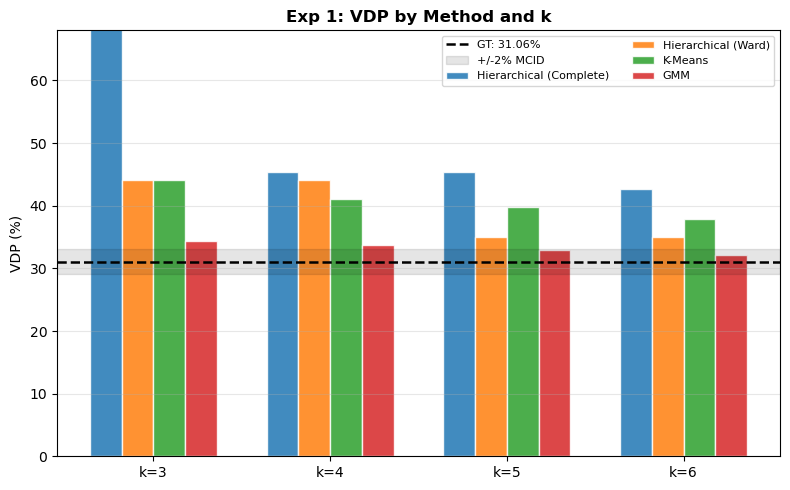

In [68]:
# fig 1a
METHOD_COLORS = dict(zip(method_names, ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']))

x, w = np.arange(len(k_values)), 0.18
fig, ax = plt.subplots(figsize=(8, 5))
for i, (method, name) in enumerate(zip(methods, method_names)):
    vdps = [results[method][k] for k in k_values]
    ax.bar(x + i*w - 1.5*w, vdps, width=w, label=name,
           color=METHOD_COLORS[name], alpha=0.85, edgecolor='white')
ax.axhline(GT_VDP, color='black', ls='--', lw=1.8, label=f'GT: {GT_VDP:.2f}%')
ax.axhspan(GT_VDP-2, GT_VDP+2, alpha=0.1, color='black', label='+/-2% MCID')
ax.set_xticks(x)
ax.set_xticklabels([f'k={k}' for k in k_values])
ax.set_ylabel('VDP (%)')
ax.set_ylim(0, 68)
ax.set_title('Exp 1: VDP by Method and k', fontweight='bold')
ax.legend(fontsize=8, ncol=2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig1a_vdp_bar.png', dpi=150, bbox_inches='tight')
plt.show()

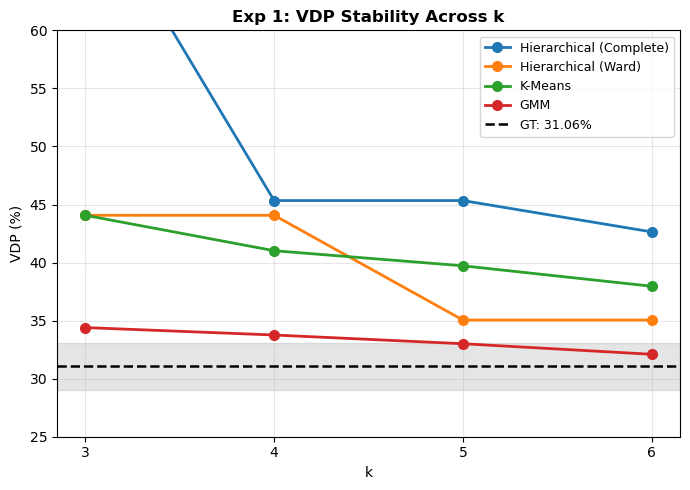

In [69]:
# fig 1b
fig, ax = plt.subplots(figsize=(7, 5))
for method, name in zip(methods, method_names):
    vdps = [results[method][k] for k in k_values]
    ax.plot(k_values, vdps, marker='o', label=name,
            color=METHOD_COLORS[name], lw=2, ms=7)
ax.axhline(GT_VDP, color='black', ls='--', lw=1.8, label=f'GT: {GT_VDP:.2f}%')
ax.axhspan(GT_VDP-2, GT_VDP+2, alpha=0.1, color='black')
ax.set_xlabel('k')
ax.set_ylabel('VDP (%)')
ax.set_ylim(25, 60)
ax.set_xticks(k_values)
ax.set_title('Exp 1: VDP Stability Across k', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig1b_vdp_line.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.2 Experiment 2: Trachea Mask Sensitivity

VDP is recomputed at k = 5 with and without the trachea included in the mask. Trachea voxels have near-zero ¹²⁹Xe signal and are always absorbed into the lowest-intensity (defect) cluster, so inclusion is expected to inflate VDP systematically. The question is how large this inflation is relative to the MCID.

In [ ]:
# VDP with and without trachea at k=5
trachea_res = {}
print(f"{'Method':<28}  No-trachea   With-trachea   Delta")
for method, name in zip(methods, method_names):
    vno = compute_vdp(xe_raw, mask_no_t, 5, method, seed=0)
    vyes = compute_vdp(xe_raw, mask_with_t, 5, method, seed=0)
    diff = round(vno - vyes, 2)
    trachea_res[method] = {'no_trachea': vno, 'with_trachea': vyes, 'diff': diff}
    print(f"{name:<28}  {vno:>9}%    {vyes:>9}%       {diff:>+.2f}%")

# check HC k=5 no-trachea should match Exp 1 exactly (same seed + mask)
exp1_hc = results['hierarchical_complete'][5]
exp2_hc = trachea_res['hierarchical_complete']['no_trachea']
print(f'\nReproducibility: Exp1={exp1_hc}%  Exp2={exp2_hc}%  '
      f'[{"OK" if abs(exp1_hc - exp2_hc) < 0.01 else "MISMATCH"}]')

Method                        No-trachea   With-trachea   Delta
Hierarchical (Complete)           45.34%         61.3%       -15.96%
Hierarchical (Ward)               35.05%        57.54%       -22.49%
K-Means                           39.72%        54.96%       -15.24%
GMM                               33.01%        38.09%       -5.08%

Reproducibility: Exp1=45.34%  Exp2=45.34%  [OK]


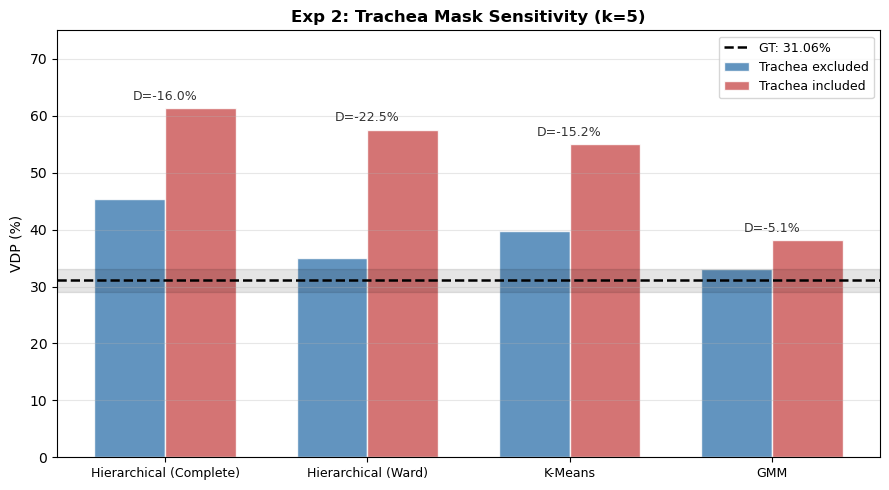

In [71]:
# fig 2
vdp_no = [trachea_res[m]['no_trachea'] for m in methods]
vdp_yes = [trachea_res[m]['with_trachea'] for m in methods]
x, w = np.arange(len(methods)), 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, vdp_no, width=w, label='Trachea excluded', color='steelblue', alpha=0.85, edgecolor='white')
ax.bar(x + w/2, vdp_yes, width=w, label='Trachea included', color='indianred', alpha=0.85, edgecolor='white')
for i, (no, yes) in enumerate(zip(vdp_no, vdp_yes)):
    ax.annotate(f'D={round(no-yes,1)}%', xy=(i, max(no, yes)+1.5), ha='center', fontsize=9, color='#333')
ax.axhline(GT_VDP, color='black', ls='--', lw=1.8, label=f'GT: {GT_VDP:.2f}%')
ax.axhspan(GT_VDP-2, GT_VDP+2, alpha=0.1, color='black')
ax.set_xticks(x)
ax.set_xticklabels(method_names, fontsize=9)
ax.set_ylabel('VDP (%)')
ax.set_ylim(0, 75)
ax.set_title('Exp 2: Trachea Mask Sensitivity (k=5)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_trachea.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.3 Experiment 3: Bootstrap Uncertainty

Bootstrap 95% confidence intervals are computed for all four methods at k = 5 (n = 500). A narrow CI relative to the MCID indicates that the method would produce stable estimates if applied to a different voxel draw from the same patient. The 2×2 panel shows all methods simultaneously for direct comparison.

In [ ]:
# Exp 3: Bootstrap uncertainty for all four clustering methods at k=5.
# For hierarchical methods: 4000-voxel subsampling applied inside each
# bootstrap iteration (same procedure as the main analysis).
# For K-Means and GMM: full bootstrap sample used
N_BOOT = 500
voxels_all = xe_raw[mask_no_t].astype(float)
rng_boot   = np.random.RandomState(42)

boot_results = {}  # method -> ndarray of N_BOOT VDP values

for method, name in zip(methods, method_names):
    boot_vdps_m = []
    for _ in range(N_BOOT):
        idx  = rng_boot.choice(len(voxels_all), len(voxels_all), replace=True)
        boot = voxels_all[idx]
        if method in ['hierarchical_complete', 'hierarchical_ward']:
            link   = 'complete' if 'complete' in method else 'ward'
            sub_i  = rng_boot.choice(len(boot), 4000, replace=False)
            sub    = boot[sub_i].reshape(-1, 1)
            Z      = linkage(sub, method=link, metric='euclidean')
            lbl    = fcluster(Z, 5, criterion='maxclust') - 1
            cents  = np.array([sub[lbl == c].mean() for c in range(5)])
            full_lbl = np.argmin(np.abs(boot[:, None] - cents[None, :]), axis=1)
        elif method == 'kmeans':
            full_lbl = KMeans(n_clusters=5, n_init=10,
                              random_state=0).fit_predict(boot.reshape(-1, 1))
        elif method == 'gmm':
            full_lbl = GaussianMixture(n_components=5, n_init=5,
                                       random_state=0).fit_predict(boot.reshape(-1, 1))
        defect = int(np.argmin([boot[full_lbl == c].mean() for c in range(5)]))
        boot_vdps_m.append(100 * np.sum(full_lbl == defect) / len(full_lbl))
    boot_results[method] = np.array(boot_vdps_m)

print(f"{'Method':<28}  {'Mean':>8}  {'Std':>6}  {'95% CI':>22}  {'Width':>8}  {'vs MCID':>9}")
for method, name in zip(methods, method_names):
    bv = boot_results[method]
    ci_lo, ci_hi = np.percentile(bv, 2.5), np.percentile(bv, 97.5)
    width = ci_hi - ci_lo
    print(f"{name:<28}  {bv.mean():>7.2f}%  {bv.std():>5.2f}%  "
          f"  [{ci_lo:.2f}%, {ci_hi:.2f}%]  {width:>7.2f}%  {width/2:.1f}x MCID")

# backward-compatible aliases for HC (used in fig 3 and report text)
boot_vdps = boot_results['hierarchical_complete']
ci_low, ci_high = np.percentile(boot_vdps, 2.5), np.percentile(boot_vdps, 97.5)
ci_width = ci_high - ci_low


Method                            Mean     Std                  95% CI     Width    vs MCID
Hierarchical (Complete)         45.02%   5.00%    [40.45%, 51.75%]    11.30%  5.7x MCID
Hierarchical (Ward)             38.88%   1.91%    [35.03%, 41.98%]     6.95%  3.5x MCID
K-Means                         39.51%   0.37%    [38.84%, 40.25%]     1.41%  0.7x MCID
GMM                             32.85%   0.44%    [31.83%, 33.46%]     1.63%  0.8x MCID


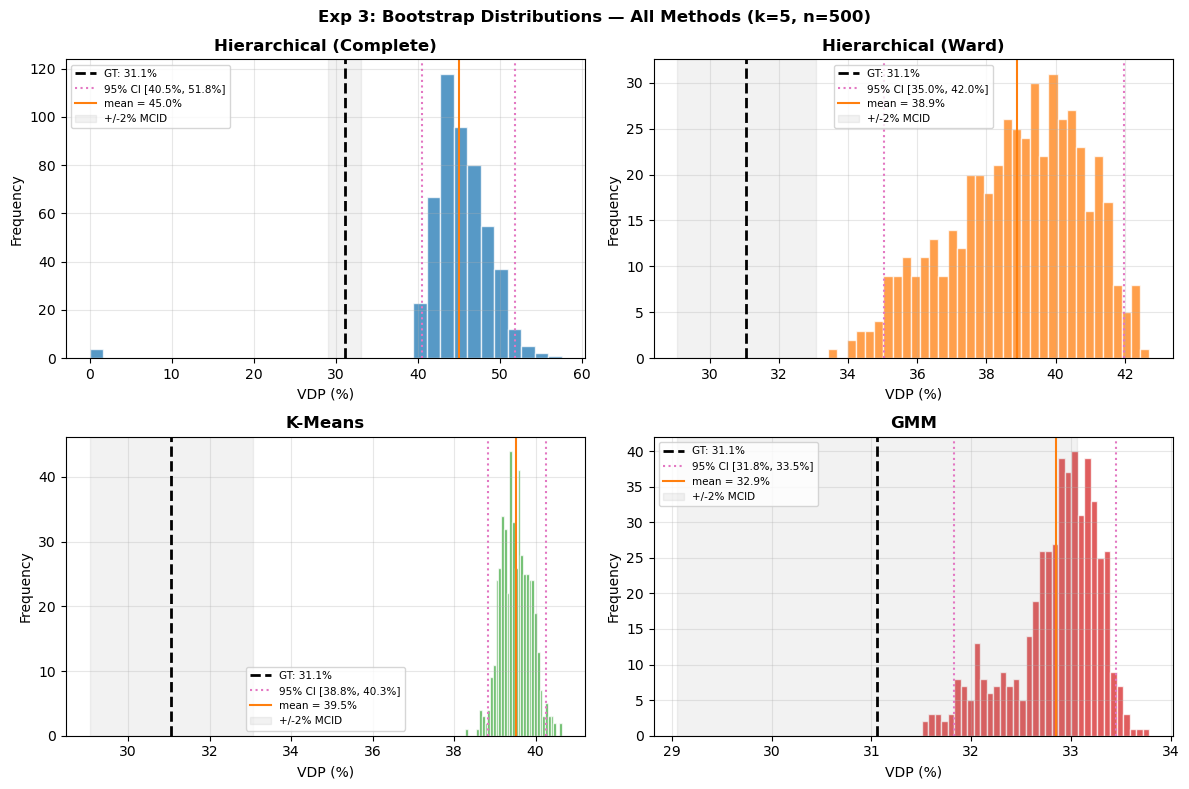

In [73]:
# fig 3b: 2x2 bootstrap distributions — all four methods
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (method, name) in zip(axes, zip(methods, method_names)):
    bv = boot_results[method]
    ci_lo, ci_hi = np.percentile(bv, 2.5), np.percentile(bv, 97.5)
    ax.hist(bv, bins=35, color=METHOD_COLORS[name], alpha=0.75, edgecolor='white')
    ax.axvline(GT_VDP,     color='black',      ls='--', lw=2,
               label=f'GT: {GT_VDP:.1f}%')
    ax.axvline(ci_lo,      color='tab:pink',   ls=':',  lw=1.5)
    ax.axvline(ci_hi,      color='tab:pink',   ls=':',  lw=1.5,
               label=f'95% CI [{ci_lo:.1f}%, {ci_hi:.1f}%]')
    ax.axvline(bv.mean(),  color='tab:orange', ls='-',  lw=1.5,
               label=f'mean = {bv.mean():.1f}%')
    ax.axvspan(GT_VDP - 2, GT_VDP + 2, alpha=0.10, color='gray', label='+/-2% MCID')
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('VDP (%)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7.5)
    ax.grid(alpha=0.3)

plt.suptitle(
    f'Exp 3: Bootstrap Distributions — All Methods (k=5, n={N_BOOT})',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('fig3b_bootstrap_all.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.4 Experiment 4: Spatial Cluster Maps

Cluster assignments are mapped back onto the 3D volume and visualized on axial slice 8/16 at k = 5. Labels are sorted by mean intensity: cluster 1 (red) = defect, cluster 5 (dark blue) = well-ventilated. This qualitative comparison shows whether spatial patterns of overestimation are consistent with the numerical results from Experiment 1.

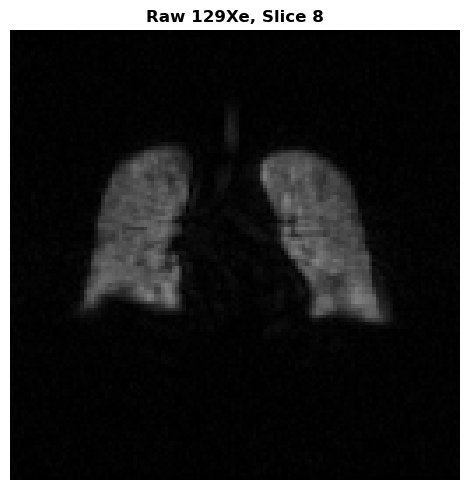

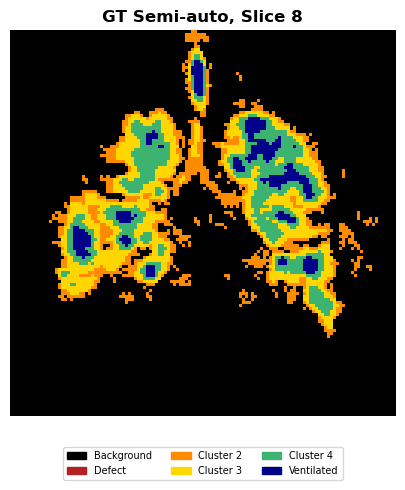

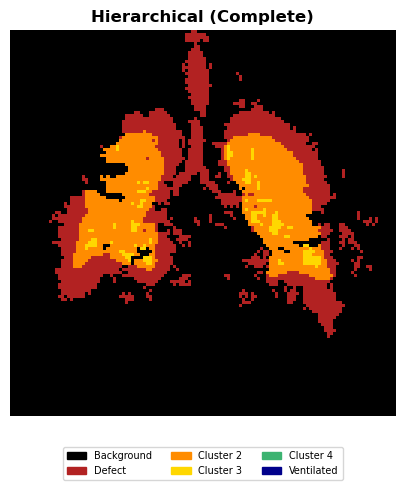

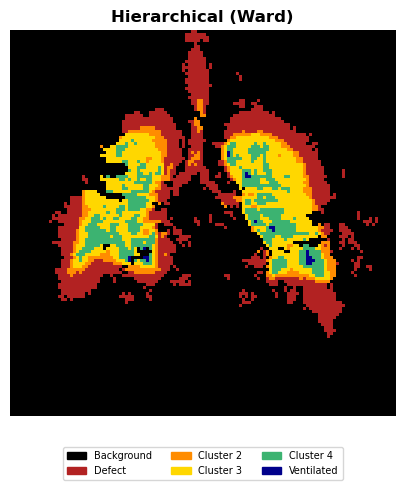

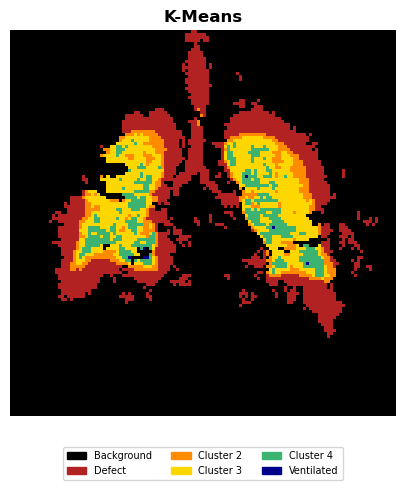

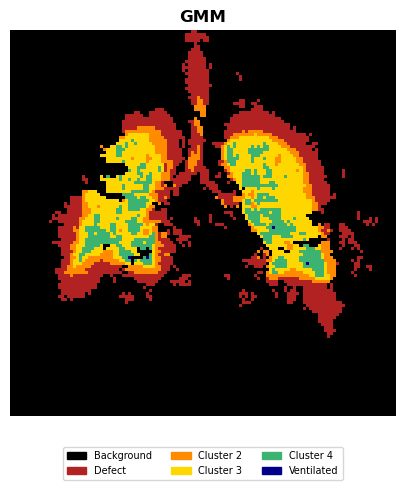

In [74]:
SLICE = 7

# 6-level colormap: background + 5 clusters sorted by intensity
cmap6 = ListedColormap(['black', 'firebrick', 'darkorange', 'gold', 'mediumseagreen', 'darkblue'])
legend_patches = [mpatches.Patch(color=c, label=l) for c, l in zip(
    ['black', 'firebrick', 'darkorange', 'gold', 'mediumseagreen', 'darkblue'],
    ['Background', 'Defect', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Ventilated'])]

# fig 4a: raw scan
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(xe_raw[:,:,SLICE], cmap='gray', vmin=0, vmax=255)
ax.set_title(f'Raw 129Xe, Slice {SLICE+1}', fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('fig4_raw.png', dpi=150, bbox_inches='tight')
plt.show()

# fig 4b: ground truth
gt_disp = np.where(mask_no_t, gt_clusters+1, 0)
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(gt_disp[:,:,SLICE], cmap=cmap6, vmin=0, vmax=5, interpolation='nearest')
ax.set_title(f'GT Semi-auto, Slice {SLICE+1}', fontweight='bold')
ax.axis('off')
plt.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=7, bbox_to_anchor=(0.5,-0.18))
plt.tight_layout()
plt.savefig('fig4_gt.png', dpi=150, bbox_inches='tight')
plt.show()

# fig 4c-f: each clustering method
fnames = ['fig4_hc.png', 'fig4_hw.png', 'fig4_km.png', 'fig4_gmm.png']
for method, name, fname in zip(methods, method_names, fnames):
    vol = get_cluster_map(xe_raw, mask_no_t, 5, method)
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(vol[:,:,SLICE], cmap=cmap6, vmin=0, vmax=5, interpolation='nearest')
    ax.set_title(name, fontweight='bold')
    ax.axis('off')
    plt.legend(handles=legend_patches, loc='lower center', ncol=3, fontsize=7, bbox_to_anchor=(0.5,-0.18))
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

### 5.5 Experiment 5: Supervised Baselines

Logistic regression and a tiny MLP (4 → 16 → 1) are trained on voxel-level ground-truth defect labels and compared against the unsupervised methods at k = 5. Both models use four features: normalized intensity and normalized spatial coordinates. Five-fold stratified cross-validation is use, VDP is computed from out-of-fold predictions.

#### Logistic Regression

In [75]:
# feature matrix: normalized intensity + spatial coords
coords = np.argwhere(mask_no_t)
voxels = xe_raw[mask_no_t].astype(float)
y = (gt_clusters[mask_no_t] == 1).astype(int)

X = np.column_stack([
    voxels / 255.0,
    coords[:, 0] / (xe_raw.shape[0] - 1),
    coords[:, 1] / (xe_raw.shape[1] - 1),
    coords[:, 2] / (xe_raw.shape[2] - 1),
])
print(f'{len(y)} voxels, {y.sum()} defect ({100*y.mean():.1f}%), {(1-y).sum()} non-defect')

# 5-fold stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_cv = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
y_oof_lr = np.zeros(len(y), dtype=int)

for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), 1):
    sc = StandardScaler()
    Xtr, Xte = sc.fit_transform(X[tr_idx]), sc.transform(X[te_idx])
    lr_f = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
    lr_f.fit(Xtr, y[tr_idx])
    prob = lr_f.predict_proba(Xte)[:, 1]
    pred = (prob >= 0.5).astype(int)
    y_oof_lr[te_idx] = pred
    lr_cv['acc'].append(accuracy_score(y[te_idx], pred))
    lr_cv['prec'].append(precision_score(y[te_idx], pred, zero_division=0))
    lr_cv['rec'].append(recall_score(y[te_idx], pred))
    lr_cv['f1'].append(f1_score(y[te_idx], pred))
    lr_cv['auc'].append(roc_auc_score(y[te_idx], prob))

print('\nLogistic Regression, 5-fold CV:')
for k, v in lr_cv.items():
    print(f'  {k:>5s}: {np.mean(v):.4f} +/- {np.std(v):.4f}')

VDP_LR = 100 * np.mean(y_oof_lr)
err_lr = abs(VDP_LR - GT_VDP)
print(f'\nVDP: {VDP_LR:.2f}%  |  GT: {GT_VDP:.2f}%  |  error: {err_lr:.2f}%')

# retrain on all data for spatial maps only
sc_full = StandardScaler()
lr_full = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
lr_full.fit(sc_full.fit_transform(X), y)
y_pred_lr = (lr_full.predict_proba(sc_full.transform(X))[:, 1] >= 0.5).astype(int)

35349 voxels, 10978 defect (31.1%), 24371 non-defect

Logistic Regression, 5-fold CV:
    acc: 0.6851 +/- 0.0038
   prec: 0.4756 +/- 0.0198
    rec: 0.1335 +/- 0.0099
     f1: 0.2082 +/- 0.0124
    auc: 0.6898 +/- 0.0030

VDP: 8.73%  |  GT: 31.06%  |  error: 22.33%


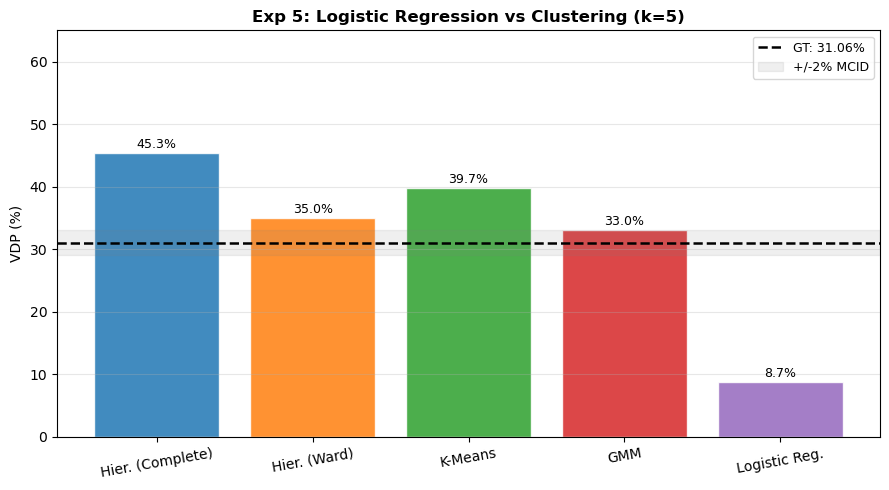

In [76]:
# fig 5a: LR vs clustering
cmp_lr = {
    'Hier. (Complete)': results['hierarchical_complete'][5],
    'Hier. (Ward)': results['hierarchical_ward'][5],
    'K-Means': results['kmeans'][5],
    'GMM': results['gmm'][5],
    'Logistic Reg.': round(VDP_LR, 2),
}
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(cmp_lr.keys(), cmp_lr.values(),
              color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple'],
              alpha=0.85, edgecolor='white')
ax.axhline(GT_VDP, color='black', ls='--', lw=1.8, label=f'GT: {GT_VDP:.2f}%')
ax.axhspan(GT_VDP-2, GT_VDP+2, color='gray', alpha=0.12, label='+/-2% MCID')
for bar, val in zip(bars, cmp_lr.values()):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.8, f'{val:.1f}%', ha='center', fontsize=9)
ax.set_ylabel('VDP (%)')
ax.set_ylim(0, 65)
ax.set_title('Exp 5: Logistic Regression vs Clustering (k=5)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('fig5a_lr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

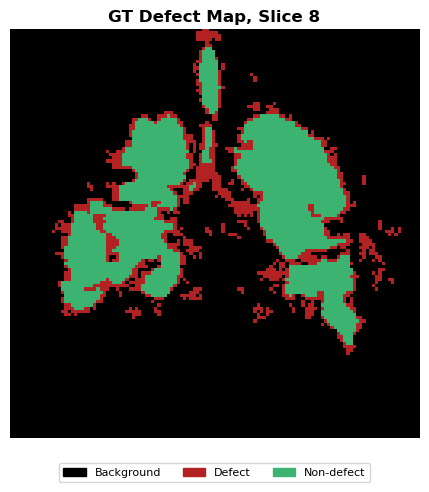

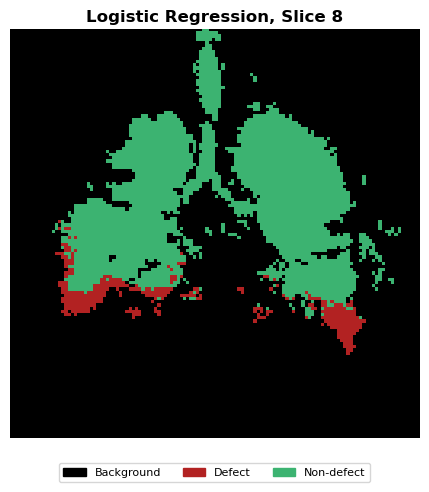

In [77]:
# binary defect colormaps
cmap_bin = ListedColormap(['black', 'firebrick', 'mediumseagreen'])
bin_patches = [mpatches.Patch(color='black', label='Background'),
               mpatches.Patch(color='firebrick', label='Defect'),
               mpatches.Patch(color='mediumseagreen', label='Non-defect')]

gt_bin = np.zeros(xe_raw.shape, dtype=int)
gt_bin[mask_no_t] = np.where(gt_clusters[mask_no_t] == 1, 1, 2)
lr_map = np.zeros(xe_raw.shape, dtype=int)
lr_map[mask_no_t] = np.where(y_pred_lr == 1, 1, 2)

# fig 5b: GT defect map
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(gt_bin[:,:,SLICE], cmap=cmap_bin, vmin=0, vmax=2, interpolation='nearest')
ax.set_title(f'GT Defect Map, Slice {SLICE+1}', fontweight='bold')
ax.axis('off')
plt.legend(handles=bin_patches, loc='lower center', ncol=3, fontsize=8, bbox_to_anchor=(0.5,-0.12))
plt.tight_layout()
plt.savefig('fig5b_gt_map.png', dpi=150, bbox_inches='tight')
plt.show()

# fig 5c: LR defect map
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(lr_map[:,:,SLICE], cmap=cmap_bin, vmin=0, vmax=2, interpolation='nearest')
ax.set_title(f'Logistic Regression, Slice {SLICE+1}', fontweight='bold')
ax.axis('off')
plt.legend(handles=bin_patches, loc='lower center', ncol=3, fontsize=8, bbox_to_anchor=(0.5,-0.12))
plt.tight_layout()
plt.savefig('fig5c_lr_map.png', dpi=150, bbox_inches='tight')
plt.show()

#### Tiny MLP

In [78]:
# 5-fold stratified CV, same splits as LR
mlp_cv = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
y_oof_mlp = np.zeros(len(y), dtype=int)

for fold, (tr_idx, te_idx) in enumerate(skf.split(X, y), 1):
    sc = StandardScaler()
    Xtr, Xte = sc.fit_transform(X[tr_idx]), sc.transform(X[te_idx])
    mlp_f = MLPClassifier(
        hidden_layer_sizes=(16,), activation='relu', solver='adam',
        alpha=1e-4, batch_size=256, learning_rate_init=1e-3,
        max_iter=300, random_state=42,
        early_stopping=True, validation_fraction=0.1, n_iter_no_change=10)
    mlp_f.fit(Xtr, y[tr_idx])
    prob = mlp_f.predict_proba(Xte)[:, 1]
    pred = (prob >= 0.5).astype(int)
    y_oof_mlp[te_idx] = pred
    mlp_cv['acc'].append(accuracy_score(y[te_idx], pred))
    mlp_cv['prec'].append(precision_score(y[te_idx], pred, zero_division=0))
    mlp_cv['rec'].append(recall_score(y[te_idx], pred))
    mlp_cv['f1'].append(f1_score(y[te_idx], pred))
    mlp_cv['auc'].append(roc_auc_score(y[te_idx], prob))

print('Tiny MLP, 5-fold CV:')
for k, v in mlp_cv.items():
    print(f'  {k:>5s}: {np.mean(v):.4f} +/- {np.std(v):.4f}')

VDP_MLP = 100 * np.mean(y_oof_mlp)
err_mlp = abs(VDP_MLP - GT_VDP)
print(f'\nVDP: {VDP_MLP:.2f}%  |  GT: {GT_VDP:.2f}%  |  error: {err_mlp:.2f}%')

# retrain on all data for spatial map only
sc_mlp = StandardScaler()
mlp_full = MLPClassifier(
    hidden_layer_sizes=(16,), activation='relu', solver='adam',
    alpha=1e-4, batch_size=256, learning_rate_init=1e-3,
    max_iter=300, random_state=42,
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=10)
mlp_full.fit(sc_mlp.fit_transform(X), y)
y_pred_mlp = (mlp_full.predict_proba(sc_mlp.transform(X))[:, 1] >= 0.5).astype(int)

Tiny MLP, 5-fold CV:
    acc: 0.7542 +/- 0.0113
   prec: 0.6588 +/- 0.0311
    rec: 0.4342 +/- 0.0155
     f1: 0.5233 +/- 0.0189
    auc: 0.7868 +/- 0.0109

VDP: 20.50%  |  GT: 31.06%  |  error: 10.56%


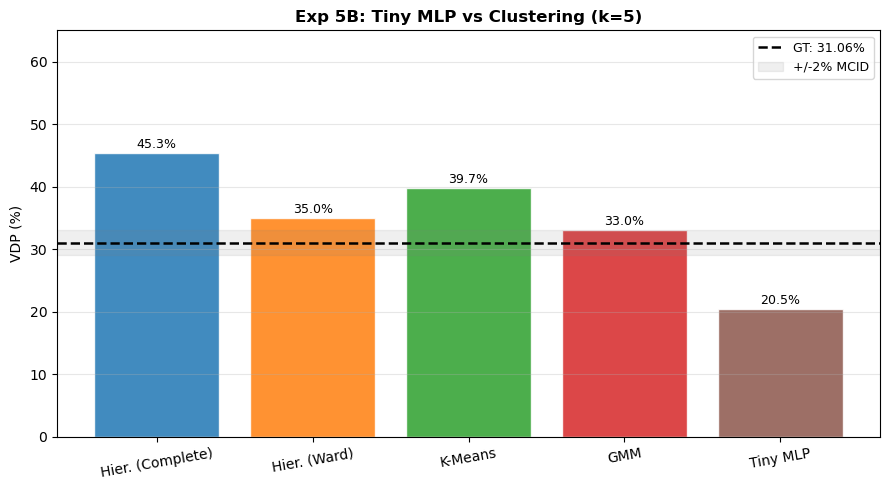

In [79]:
# fig 5d: MLP vs clustering
cmp_mlp = {
    'Hier. (Complete)': results['hierarchical_complete'][5],
    'Hier. (Ward)': results['hierarchical_ward'][5],
    'K-Means': results['kmeans'][5],
    'GMM': results['gmm'][5],
    'Tiny MLP': round(VDP_MLP, 2),
}
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(cmp_mlp.keys(), cmp_mlp.values(),
              color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:brown'],
              alpha=0.85, edgecolor='white')
ax.axhline(GT_VDP, color='black', ls='--', lw=1.8, label=f'GT: {GT_VDP:.2f}%')
ax.axhspan(GT_VDP-2, GT_VDP+2, color='gray', alpha=0.12, label='+/-2% MCID')
for bar, val in zip(bars, cmp_mlp.values()):
    ax.text(bar.get_x()+bar.get_width()/2, val+0.8, f'{val:.1f}%', ha='center', fontsize=9)
ax.set_ylabel('VDP (%)')
ax.set_ylim(0, 65)
ax.set_title('Exp 5B: Tiny MLP vs Clustering (k=5)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('fig5d_mlp_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

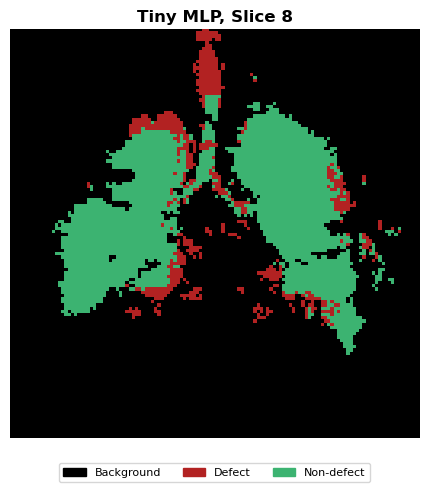

In [80]:
# fig 5e: MLP defect map
mlp_map = np.zeros(xe_raw.shape, dtype=int)
mlp_map[mask_no_t] = np.where(y_pred_mlp == 1, 1, 2)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(mlp_map[:,:,SLICE], cmap=cmap_bin, vmin=0, vmax=2, interpolation='nearest')
ax.set_title(f'Tiny MLP, Slice {SLICE+1}', fontweight='bold')
ax.axis('off')
plt.legend(handles=bin_patches, loc='lower center', ncol=3, fontsize=8, bbox_to_anchor=(0.5,-0.12))
plt.tight_layout()
plt.savefig('fig5e_mlp_map.png', dpi=150, bbox_inches='tight')
plt.show()

#### Baselines Summary

Cross-validated classification metrics and VDP estimates for both supervised models.

In [81]:
def fmt(vals):
    return f'{np.mean(vals):.3f} +/- {np.std(vals):.3f}'

header = (f"{'Model':<22} {'Accuracy':>16} {'Precision':>16} {'Recall':>16}"
          f" {'F1':>16} {'ROC AUC':>16} {'VDP (%)':>9} {'|err|':>8}")
print(header)
for name, cv, vdp_val, err_val in [
    ('Logistic Regression', lr_cv, VDP_LR, err_lr),
    ('Tiny MLP', mlp_cv, VDP_MLP, err_mlp),
]:
    row = (f"{name:<22}"
           f" {fmt(cv['acc']):>16}"
           f" {fmt(cv['prec']):>16}"
           f" {fmt(cv['rec']):>16}"
           f" {fmt(cv['f1']):>16}"
           f" {fmt(cv['auc']):>16}"
           f" {vdp_val:>8.2f}%"
           f" {err_val:>7.2f}%")
    print(row)
print(f"\n{'GT Semi-auto':<22}" + ' ' * 80 + f" {GT_VDP:>8.2f}%")

Model                          Accuracy        Precision           Recall               F1          ROC AUC   VDP (%)    |err|
Logistic Regression     0.685 +/- 0.004  0.476 +/- 0.020  0.133 +/- 0.010  0.208 +/- 0.012  0.690 +/- 0.003     8.73%   22.33%
Tiny MLP                0.754 +/- 0.011  0.659 +/- 0.031  0.434 +/- 0.016  0.523 +/- 0.019  0.787 +/- 0.011    20.50%   10.56%

GT Semi-auto                                                                                              31.06%


### 5.6 Experiment 6: Multi-Patient Generalizability

Experiments 1 and 3 are repeated on the 10-patient ¹²⁹Xe cohort described in Section 3.2. Because the cohort lacks trachea masks and voxel-level GT labels, Experiments 2, 4, and 5 are not run here. GT VDP for each patient comes from `VDPinfo.mat`. The goal is to assess whether the method-stability rankings observed on the single patient hold across patients with different disease severities (GT VDP ranging from ~1% to ~36%).

In [ ]:
from scipy.ndimage import zoom

XE_BASE = '/Users/omarrahman/Downloads/Xe vs 19F processing code and data/High_res_Xe'

patient_ids = ['2569-005', '2569-006', '2569-007', '2569-008', '2569-009',
               '2569-010', '2569-011', '2569-012', '2569-013', '2569-015']

# GT VDP from VDPinfo.mat -- order matches patient_ids
vdp_info   = scipy.io.loadmat(f'{XE_BASE}/outputs/VentMaps/VDPinfo.mat')
gt_vdps_mp = vdp_info['VDP_Xe'].flatten()

print(f"{'Patient':<12}  {'GT VDP':>8}")
for pid, gt in zip(patient_ids, gt_vdps_mp):
    print(f'  {pid}        {gt:.2f}%')

Patient         GT VDP
  2569-005        28.55%
  2569-006        23.79%
  2569-007        1.40%
  2569-008        21.98%
  2569-009        21.40%
  2569-010        19.47%
  2569-011        11.49%
  2569-012        17.96%
  2569-013        35.73%
  2569-015        11.94%


In [83]:
# FUNC: int16 Xe scan; ANATOM_ROI: uint8 lung mask
# some patients have ROI at 4x scan resolution (512x640), others already match (128x160)
# downsample with block max-pooling only when needed; normalize scan to [0, 255]
patient_data = {}

for pid in patient_ids:
    xe_mat  = scipy.io.loadmat(f'{XE_BASE}/data/{pid}_XE.mat')
    roi_mat = scipy.io.loadmat(f'{XE_BASE}/data/{pid}_ROI.mat')

    xe  = xe_mat['FUNC'].astype(float)
    roi = roi_mat['ANATOM_ROI']

    xe = np.clip(xe, 0, None)
    if xe.max() > 0:
        xe = xe / xe.max() * 255.0

    # downsample ROI if it's at 4x resolution, otherwise use directly
    R, C, S = xe.shape
    if roi.shape[:2] == (R*4, C*4):
        mask = roi.reshape(R, 4, C, 4, S).max(axis=(1, 3)) > 0
    else:
        mask = roi > 0

    patient_data[pid] = {'xe': xe, 'mask': mask}
    print(f'{pid}  ROI={roi.shape}  XE={xe.shape}  mask voxels={mask.sum():>6}')

2569-005  ROI=(512, 640, 18)  XE=(128, 160, 18)  mask voxels= 58621
2569-006  ROI=(512, 640, 18)  XE=(128, 160, 18)  mask voxels= 61491
2569-007  ROI=(512, 640, 16)  XE=(128, 160, 16)  mask voxels= 58555
2569-008  ROI=(128, 160, 18)  XE=(128, 160, 18)  mask voxels= 67121
2569-009  ROI=(128, 160, 18)  XE=(128, 160, 18)  mask voxels= 82052
2569-010  ROI=(128, 160, 18)  XE=(128, 160, 18)  mask voxels= 55035
2569-011  ROI=(128, 160, 18)  XE=(128, 160, 18)  mask voxels= 73475
2569-012  ROI=(128, 160, 19)  XE=(128, 160, 19)  mask voxels= 93367
2569-013  ROI=(128, 160, 18)  XE=(128, 160, 18)  mask voxels= 84749
2569-015  ROI=(128, 160, 18)  XE=(128, 160, 18)  mask voxels= 54031


In [84]:
# Exp 6a: k-sweep for all 10 patients, same methods and k values as Exp 1
mp_results = {}  # patient -> method -> k -> VDP

for pid in patient_ids:
    xe_p, mask_p    = patient_data[pid]['xe'], patient_data[pid]['mask']
    mp_results[pid] = {m: {k: compute_vdp(xe_p, mask_p, k, m, seed=0)
                            for k in k_values}
                       for m in methods}

print(f"{'Patient':<12}  {'GT':>7}  {'HC':>7}  {'Ward':>7}  {'KMeans':>7}  {'GMM':>7}")
for pid, gt in zip(patient_ids, gt_vdps_mp):
    k5 = [mp_results[pid][m][5] for m in methods]
    print(f"{pid:<12}  {gt:>6.2f}%  " + "  ".join(f"{v:>6.2f}%" for v in k5))

print(f'\nMCID: +/-2%')

Patient            GT       HC     Ward   KMeans      GMM
2569-005       28.55%   60.13%   42.43%   38.81%   36.61%
2569-006       23.79%   78.07%   42.19%   36.47%   32.68%
2569-007        1.40%   23.32%   13.15%   13.61%   13.01%
2569-008       21.98%   35.72%   28.18%   24.38%   22.57%
2569-009       21.40%   53.23%   43.14%   37.43%   26.31%
2569-010       19.47%   53.12%   31.61%   34.67%   28.01%
2569-011       11.49%   38.12%   24.06%   26.73%   17.54%
2569-012       17.96%   25.25%   32.75%   25.97%   23.80%
2569-013       35.73%   47.67%   31.20%   37.27%   35.23%
2569-015       11.94%   24.52%   13.63%   18.72%   16.74%

MCID: +/-2%


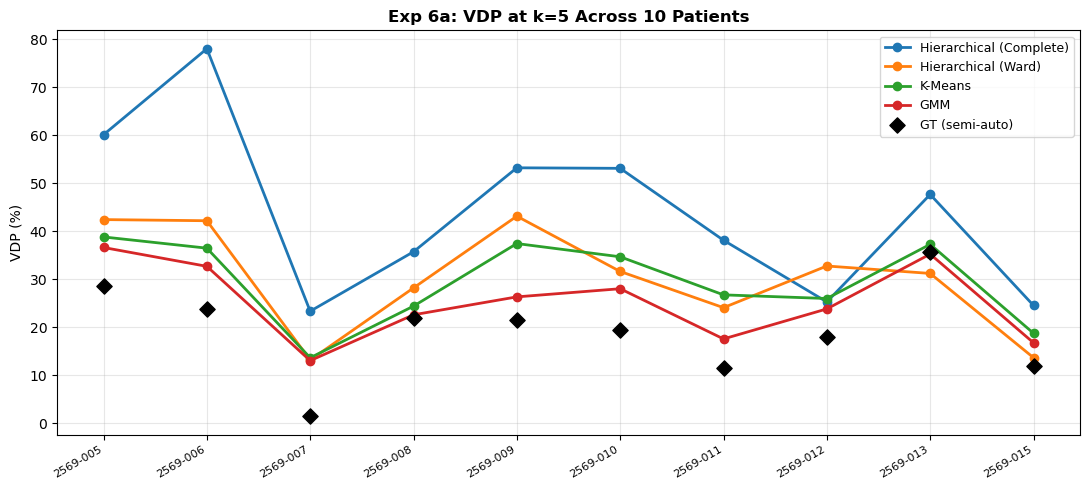

In [85]:
# fig 6a: VDP at k=5 for all 10 patients, one line per method + GT as diamonds
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(patient_ids))
for method, name in zip(methods, method_names):
    vdps = [mp_results[pid][method][5] for pid in patient_ids]
    ax.plot(x, vdps, marker='o', label=name, color=METHOD_COLORS[name], lw=2, ms=6)
ax.scatter(x, gt_vdps_mp, color='black', zorder=5, s=60, marker='D', label='GT (semi-auto)')
ax.set_xticks(x)
ax.set_xticklabels(patient_ids, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('VDP (%)')
ax.set_title('Exp 6a: VDP at k=5 Across 10 Patients', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig6a_mp_vdp_k5.png', dpi=150, bbox_inches='tight')
plt.show()

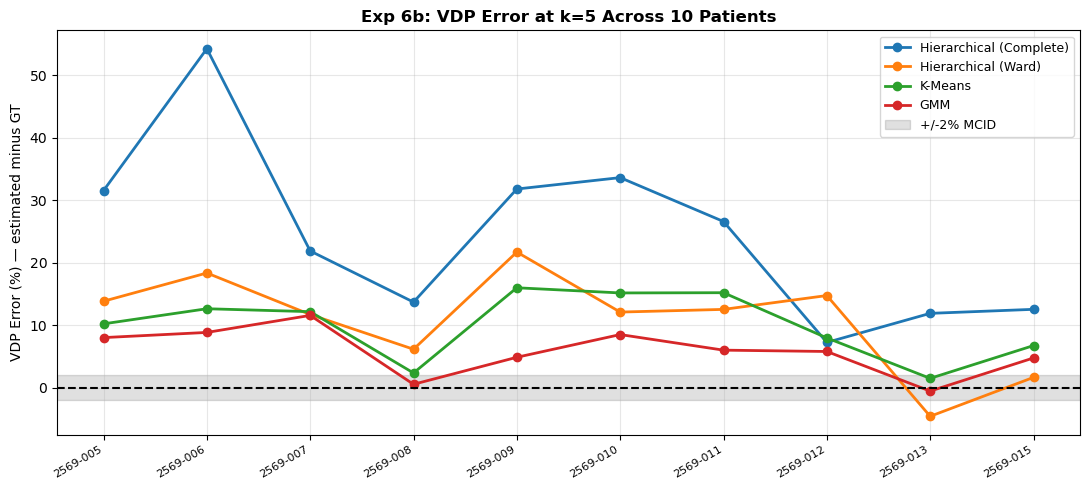

In [86]:
# fig 6b: VDP error (estimated - GT) at k=5 per patient
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(patient_ids))
for method, name in zip(methods, method_names):
    errs = [mp_results[pid][method][5] - gt
            for pid, gt in zip(patient_ids, gt_vdps_mp)]
    ax.plot(x, errs, marker='o', label=name, color=METHOD_COLORS[name], lw=2, ms=6)
ax.axhline(0, color='black', ls='--', lw=1.5)
ax.axhspan(-2, 2, alpha=0.12, color='black', label='+/-2% MCID')
ax.set_xticks(x)
ax.set_xticklabels(patient_ids, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('VDP Error (%) — estimated minus GT')
ax.set_title('Exp 6b: VDP Error at k=5 Across 10 Patients', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig6b_mp_vdp_error.png', dpi=150, bbox_inches='tight')
plt.show()

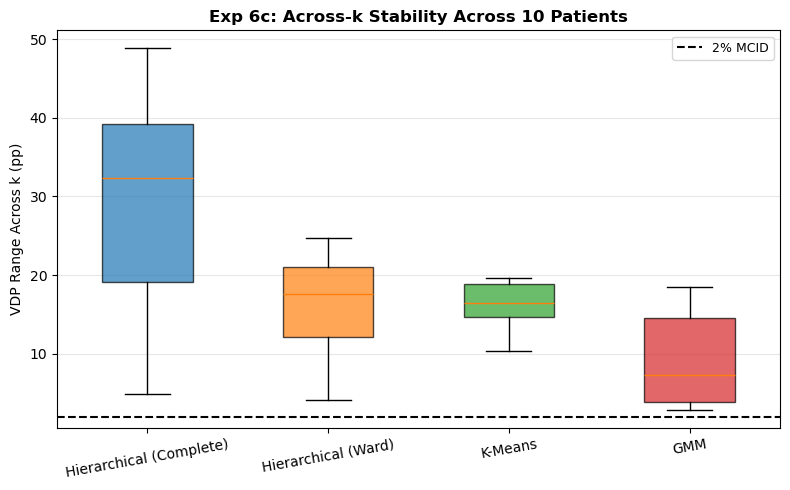

In [87]:
# fig 6c: across-k stability -- range of VDP over k in {3,4,5,6} per patient, boxplot per method
fig, ax = plt.subplots(figsize=(8, 5))
ranges_by_method = []
for method in methods:
    ranges = [max(mp_results[pid][method][k] for k in k_values) -
              min(mp_results[pid][method][k] for k in k_values)
              for pid in patient_ids]
    ranges_by_method.append(ranges)

bp = ax.boxplot(ranges_by_method, labels=method_names, patch_artist=True, widths=0.5)
for patch, name in zip(bp['boxes'], method_names):
    patch.set_facecolor(METHOD_COLORS[name])
    patch.set_alpha(0.7)
ax.axhline(2, color='black', ls='--', lw=1.5, label='2% MCID')
ax.set_ylabel('VDP Range Across k (pp)')
ax.set_title('Exp 6c: Across-k Stability Across 10 Patients', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('fig6c_mp_range_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

In [88]:
# Exp 6b: bootstrap uncertainty for all 10 patients at k=5
# n=200 per patient (reduced from 500 to keep runtime manageable across 10 patients)
N_BOOT_MP = 200
rng_mp    = np.random.RandomState(42)
mp_boot   = {}  # patient -> method -> ndarray of N_BOOT_MP VDP values

for pid in patient_ids:
    xe_p, mask_p = patient_data[pid]['xe'], patient_data[pid]['mask']
    vox_p        = xe_p[mask_p].astype(float)
    mp_boot[pid] = {}

    for method in methods:
        boot_v = []
        for _ in range(N_BOOT_MP):
            idx  = rng_mp.choice(len(vox_p), len(vox_p), replace=True)
            boot = vox_p[idx]
            if method in ['hierarchical_complete', 'hierarchical_ward']:
                link  = 'complete' if 'complete' in method else 'ward'
                sub_i = rng_mp.choice(len(boot), 4000, replace=False)
                sub   = boot[sub_i].reshape(-1, 1)
                Z     = linkage(sub, method=link, metric='euclidean')
                lbl   = fcluster(Z, 5, criterion='maxclust') - 1
                cents = np.array([sub[lbl == c].mean() for c in range(5)])
                full_lbl = np.argmin(np.abs(boot[:, None] - cents[None, :]), axis=1)
            elif method == 'kmeans':
                full_lbl = KMeans(n_clusters=5, n_init=10,
                                  random_state=0).fit_predict(boot.reshape(-1, 1))
            elif method == 'gmm':
                full_lbl = GaussianMixture(n_components=5, n_init=5,
                                           random_state=0).fit_predict(boot.reshape(-1, 1))
            defect = int(np.argmin([boot[full_lbl == c].mean() for c in range(5)]))
            boot_v.append(100 * np.sum(full_lbl == defect) / len(full_lbl))
        mp_boot[pid][method] = np.array(boot_v)
    print(f'{pid} done')

# median CI width per method across all 10 patients
print(f"\n{'Method':<28}  {'Median CI Width':>16}  {'Max CI Width':>14}")
for method, name in zip(methods, method_names):
    widths = [np.percentile(mp_boot[pid][method], 97.5) -
              np.percentile(mp_boot[pid][method], 2.5)
              for pid in patient_ids]
    print(f"{name:<28}  {np.median(widths):>15.2f}%  {max(widths):>13.2f}%")

2569-005 done
2569-006 done
2569-007 done
2569-008 done
2569-009 done
2569-010 done
2569-011 done
2569-012 done
2569-013 done
2569-015 done

Method                         Median CI Width    Max CI Width
Hierarchical (Complete)                 27.33%          39.21%
Hierarchical (Ward)                     15.00%          20.00%
K-Means                                  2.17%           2.60%
GMM                                      1.90%           2.58%


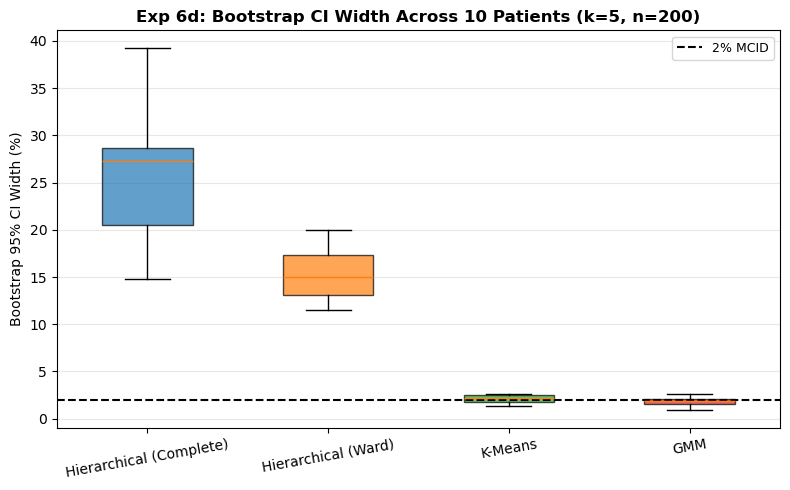

In [89]:
# fig 6d: bootstrap 95% CI width distribution across 10 patients, one box per method
fig, ax = plt.subplots(figsize=(8, 5))
ci_widths_all = []
for method in methods:
    widths = [np.percentile(mp_boot[pid][method], 97.5) -
              np.percentile(mp_boot[pid][method], 2.5)
              for pid in patient_ids]
    ci_widths_all.append(widths)

bp = ax.boxplot(ci_widths_all, labels=method_names, patch_artist=True, widths=0.5)
for patch, name in zip(bp['boxes'], method_names):
    patch.set_facecolor(METHOD_COLORS[name])
    patch.set_alpha(0.7)
ax.axhline(2, color='black', ls='--', lw=1.5, label='2% MCID')
ax.set_ylabel('Bootstrap 95% CI Width (%)')
ax.set_title(f'Exp 6d: Bootstrap CI Width Across 10 Patients (k=5, n={N_BOOT_MP})', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig('fig6d_mp_ci_widths.png', dpi=150, bbox_inches='tight')
plt.show()

In [90]:
# Exp 6 summary: median |error| and CI width across all 10 patients at k=5
print('Exp 6 Summary (k=5, trachea-excluded ROI mask)')
print(f"{'Method':<28}  {'Median |err|':>14}  {'Median CI Width':>16}  {'CI vs MCID':>12}")
for method, name in zip(methods, method_names):
    errs   = [abs(mp_results[pid][method][5] - gt)
              for pid, gt in zip(patient_ids, gt_vdps_mp)]
    widths = [np.percentile(mp_boot[pid][method], 97.5) -
              np.percentile(mp_boot[pid][method], 2.5)
              for pid in patient_ids]
    med_err = np.median(errs)
    med_w   = np.median(widths)
    print(f"{name:<28}  {med_err:>13.2f}%  {med_w:>15.2f}%  {med_w/2:.1f}x MCID")
print('\nSingle-patient results (Exp 1/3) shown above for reference.')

Exp 6 Summary (k=5, trachea-excluded ROI mask)
Method                          Median |err|   Median CI Width    CI vs MCID
Hierarchical (Complete)               24.28%            27.33%  13.7x MCID
Hierarchical (Ward)                   12.36%            15.00%  7.5x MCID
K-Means                               11.23%             2.17%  1.1x MCID
GMM                                    5.94%             1.90%  0.9x MCID

Single-patient results (Exp 1/3) shown above for reference.


## 6. Summary and Discussion

Key findings across experiments:

- Algorithm choice dominates: across-method VDP spread at k=5 = 12.33% >> 2% MCID
- Hierarchical Complete (published method): largest across-k range (29.81%), largest error at k=5 (14.28%)
- GMM most stable: across-k range 2.30%; only method with sub-MCID error at k=5 (1.95%)
- Trachea masking (Exp 2): inclusion inflates VDP by 15–22% for hard clustering — validity condition, not optional
- Supervised baselines underperform: per-voxel features lack distributional context → larger VDP errors
- Cohort (Exp 6): k-sweep and bootstrap rankings from single patient assessed across 10 patients (GT VDP ~1–36%)

Collected tables below.


In [91]:
# collected results
print('Table 1: VDP (%) by method and k (trachea excluded)')
hdr = f"{'Method':<28} {'k=3':>8} {'k=4':>8} {'k=5':>8} {'k=6':>8} {'Range':>8}"
print(hdr)
for method, name in zip(methods, method_names):
    vals = [results[method][k] for k in k_values]
    rng = max(vals) - min(vals)
    print(f"{name:<28}" + "".join(f" {v:>7.2f}%" for v in vals) + f" {rng:>7.2f}%")
print(f"{'GT Semi-auto':<28} {'--':>8} {'--':>8} {GT_VDP:>7.2f}% {'--':>8} {'--':>8}")
print()

print('Table 2: Trachea sensitivity (k=5)')
hdr2 = f"{'Method':<28} {'No-trachea':>12} {'With-trachea':>14} {'Delta':>8}"
print(hdr2)
for method, name in zip(methods, method_names):
    t = trachea_res[method]
    print(f"{name:<28} {t['no_trachea']:>11.2f}% {t['with_trachea']:>13.2f}% {t['diff']:>+7.2f}%")
print()

print('Table 3: Bootstrap (Hierarchical Complete, k=5, n=500)')
print(f'  mean={boot_vdps.mean():.2f}%  std={boot_vdps.std():.2f}%  95% CI=[{ci_low:.2f}%, {ci_high:.2f}%]  width={ci_width:.2f}%')
print()
print('Table 4: Bootstrap 95% CI summary — all methods (k=5, n=500)')
hdr4 = (f"{'Method':<28} {'Mean':>8} {'Std':>7} "
        f"{'CI low':>9} {'CI high':>9} {'Width':>8} {'vs MCID':>9}")
print(hdr4)
for method, name in zip(methods, method_names):
    bv = boot_results[method]
    ci_lo, ci_hi = np.percentile(bv, 2.5), np.percentile(bv, 97.5)
    width = ci_hi - ci_lo
    print(f"{name:<28} {bv.mean():>7.2f}% {bv.std():>6.2f}% "
          f"{ci_lo:>8.2f}% {ci_hi:>8.2f}% {width:>7.2f}% {width/2:.1f}x MCID")


Table 1: VDP (%) by method and k (trachea excluded)
Method                            k=3      k=4      k=5      k=6    Range
Hierarchical (Complete)        72.45%   45.34%   45.34%   42.64%   29.81%
Hierarchical (Ward)            44.07%   44.07%   35.05%   35.05%    9.02%
K-Means                        44.07%   41.02%   39.72%   37.96%    6.11%
GMM                            34.40%   33.76%   33.01%   32.10%    2.30%
GT Semi-auto                       --       --   31.06%       --       --

Table 2: Trachea sensitivity (k=5)
Method                         No-trachea   With-trachea    Delta
Hierarchical (Complete)            45.34%         61.30%  -15.96%
Hierarchical (Ward)                35.05%         57.54%  -22.49%
K-Means                            39.72%         54.96%  -15.24%
GMM                                33.01%         38.09%   -5.08%

Table 3: Bootstrap (Hierarchical Complete, k=5, n=500)
  mean=45.02%  std=5.00%  95% CI=[40.45%, 51.75%]  width=11.30%

Table 4: Bootstra

In [92]:
# full comparison at k=5
all_methods = {
    'Hierarchical (Complete)': results['hierarchical_complete'][5],
    'Hierarchical (Ward)': results['hierarchical_ward'][5],
    'K-Means': results['kmeans'][5],
    'GMM': results['gmm'][5],
    'Logistic Regression': round(VDP_LR, 2),
    'Tiny MLP': round(VDP_MLP, 2),
}

print(f"{'Method':<28} {'VDP':>8} {'|error|':>10} {'vs MCID':>12}")
for name, vdp in all_methods.items():
    err = abs(vdp - GT_VDP)
    verdict = f'{err/2:.1f}x MCID' if err >= 2 else '< MCID'
    print(f"{name:<28} {vdp:>7.2f}% {err:>10.2f}% {verdict:>12}")
print(f"{'GT Semi-auto':<28} {GT_VDP:>7.2f}%")

Method                            VDP    |error|      vs MCID
Hierarchical (Complete)        45.34%      14.28%    7.1x MCID
Hierarchical (Ward)            35.05%       3.99%    2.0x MCID
K-Means                        39.72%       8.66%    4.3x MCID
GMM                            33.01%       1.95%       < MCID
Logistic Regression             8.73%      22.33%   11.2x MCID
Tiny MLP                       20.50%      10.56%    5.3x MCID
GT Semi-auto                   31.06%


## 7. Conclusion

- VDP is sensitive to algorithm choice and trachea masking — both can shift estimates by >> 2% MCID
- GMM at k=5: only sub-MCID error (1.95%) on single patient; narrowest bootstrap CI
- Hierarchical Complete: largest error (14.28%), widest CI (11.30%) — note for pipeline users
- Supervised baselines confirm unsupervised formulation is better-suited for distributional VDP estimation
- Exp 6 extends findings to 10-patient cohort (GT VDP range: ~1–36%) — checks generalizability of rankings

**Suggested follow-up:** GMM as pipeline alternative; standardized trachea exclusion; bootstrap CI reported alongside point estimates; larger multi-centre cohort validation


---

## Supplementary Material

Additional experiments supporting the main report. These do not affect any results above and can be run independently after Experiments 1–6 have completed.

- **S1** Computational timing benchmarks
- **S2** Hyperparameter sensitivity (LR regularization, MLP architecture)
- **S3** PyTorch MLP reimplementation
- **S4** Intensity histogram with GMM and K-Means overlays
- **S5** Single-method bootstrap histogram (Hierarchical Complete only)
- **S6** Supplementary summary

In [93]:
# setup: create X_scaled for supplementary experiments
# (same features as above, but pre-scaled for convenience)
from sklearn.preprocessing import StandardScaler

coords = np.argwhere(mask_no_t)
voxels_sup = xe_raw[mask_no_t].astype(float)
y_sup = (gt_clusters[mask_no_t] == 1).astype(int)

X_sup = np.column_stack([
    voxels_sup / 255.0,
    coords[:, 0] / (xe_raw.shape[0] - 1),
    coords[:, 1] / (xe_raw.shape[1] - 1),
    coords[:, 2] / (xe_raw.shape[2] - 1),
])

scaler_sup = StandardScaler()
X_scaled = scaler_sup.fit_transform(X_sup)
y = y_sup

print(f'Supplementary setup: {len(y)} voxels, X_scaled shape {X_scaled.shape}')

Supplementary setup: 35349 voxels, X_scaled shape (35349, 4)


### S1: Computational Timing Benchmarks

Times each clustering method over 5 runs at k=5.

In [94]:
import time

def time_method(method, n_runs=5):
    """Time a clustering method over n_runs, return mean and std in ms."""
    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        compute_vdp(xe_raw, mask_no_t, 5, method, seed=0)
        times.append((time.perf_counter() - t0) * 1000)
    return np.mean(times), np.std(times)

print('Timing Benchmarks (k=5, n=5 runs)')
print(f"{'Method':<28} {'Mean (ms)':>12} {'Std (ms)':>12}")

timing_results = {}
for method, name in zip(methods, method_names):
    mean_t, std_t = time_method(method)
    timing_results[method] = (mean_t, std_t)
    print(f"{name:<28} {mean_t:>11.2f} {std_t:>11.2f}")

# supervised baselines timing
t0 = time.perf_counter()
_ = LogisticRegression(C=1.0, max_iter=1000, random_state=42).fit(X_scaled, y)
lr_time = (time.perf_counter() - t0) * 1000

t0 = time.perf_counter()
_ = MLPClassifier(hidden_layer_sizes=(16,), max_iter=500, random_state=42,
                  early_stopping=True).fit(X_scaled, y)
mlp_time = (time.perf_counter() - t0) * 1000

print(f"{'Logistic Regression':<28} {lr_time:>11.2f} {'(1 run)':>12}")
print(f"{'Tiny MLP (sklearn)':<28} {mlp_time:>11.2f} {'(1 run)':>12}")

Timing Benchmarks (k=5, n=5 runs)
Method                          Mean (ms)     Std (ms)
Hierarchical (Complete)            74.46        7.73
Hierarchical (Ward)                79.24        0.51
K-Means                            45.48        2.06
GMM                               429.14       22.86
Logistic Regression                19.74      (1 run)
Tiny MLP (sklearn)               1506.21      (1 run)


### S2: Hyperparameter Sensitivity

Varies LR regularization strength C and MLP hidden-layer size. Shows VDP error and classification metrics across configurations.

In [95]:
# logistic regression: vary regularization strength C
C_vals = [0.01, 0.1, 1.0, 10.0, 100.0]
lr_hp_results = []

print('Logistic Regression: Regularization Sensitivity')
print(f"{'C':<10} {'Accuracy':>12} {'ROC AUC':>12} {'VDP (%)':>10} {'|err|':>10}")

for C in C_vals:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    accs, aucs = [], []
    for train_idx, test_idx in skf.split(X_scaled, y):
        clf = LogisticRegression(C=C, max_iter=1000, random_state=42)
        clf.fit(X_scaled[train_idx], y[train_idx])
        pred = clf.predict(X_scaled[test_idx])
        prob = clf.predict_proba(X_scaled[test_idx])[:, 1]
        accs.append(accuracy_score(y[test_idx], pred))
        aucs.append(roc_auc_score(y[test_idx], prob))
    
    clf = LogisticRegression(C=C, max_iter=1000, random_state=42).fit(X_scaled, y)
    vdp_hp = 100 * clf.predict(X_scaled).mean()
    err = abs(vdp_hp - GT_VDP)
    lr_hp_results.append((C, np.mean(accs), np.mean(aucs), vdp_hp, err))
    print(f"{C:<10} {np.mean(accs):>11.3f} {np.mean(aucs):>11.3f} {vdp_hp:>9.2f}% {err:>9.2f}%")

Logistic Regression: Regularization Sensitivity
C              Accuracy      ROC AUC    VDP (%)      |err|
0.01             0.686       0.690      7.97%     23.09%
0.1              0.685       0.690      8.68%     22.37%
1.0              0.685       0.690      8.74%     22.31%
10.0             0.685       0.690      8.75%     22.30%
100.0            0.685       0.690      8.76%     22.30%


In [96]:
# MLP: vary hidden layer size
hidden_sizes = [(8,), (16,), (32,), (64,), (16, 8), (32, 16)]
mlp_hp_results = []

print('MLP: Architecture Sensitivity')
print(f"{'Hidden':<14} {'Accuracy':>12} {'ROC AUC':>12} {'VDP (%)':>10} {'|err|':>10}")

for hs in hidden_sizes:
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    accs, aucs = [], []
    for train_idx, test_idx in skf.split(X_scaled, y):
        clf = MLPClassifier(hidden_layer_sizes=hs, max_iter=500, random_state=42,
                            early_stopping=True, validation_fraction=0.15)
        clf.fit(X_scaled[train_idx], y[train_idx])
        pred = clf.predict(X_scaled[test_idx])
        prob = clf.predict_proba(X_scaled[test_idx])[:, 1]
        accs.append(accuracy_score(y[test_idx], pred))
        aucs.append(roc_auc_score(y[test_idx], prob))
    
    clf = MLPClassifier(hidden_layer_sizes=hs, max_iter=500, random_state=42,
                        early_stopping=True).fit(X_scaled, y)
    vdp_hp = 100 * clf.predict(X_scaled).mean()
    err = abs(vdp_hp - GT_VDP)
    mlp_hp_results.append((hs, np.mean(accs), np.mean(aucs), vdp_hp, err))
    print(f"{str(hs):<14} {np.mean(accs):>11.3f} {np.mean(aucs):>11.3f} {vdp_hp:>9.2f}% {err:>9.2f}%")

MLP: Architecture Sensitivity
Hidden             Accuracy      ROC AUC    VDP (%)      |err|
(8,)                 0.740       0.768     20.73%     10.33%
(16,)                0.756       0.791     19.96%     11.10%
(32,)                0.762       0.797     20.58%     10.47%
(64,)                0.780       0.819     20.04%     11.02%
(16, 8)              0.798       0.836     22.72%      8.33%
(32, 16)             0.811       0.862     25.34%      5.71%


### S3: PyTorch MLP Reimplementation

Reimplements the tiny MLP baseline in PyTorch (4 → 16 → 1) with early stopping on validation loss. Architecture matches the sklearn version.

In [97]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class VoxelMLP(nn.Module):
    """Binary classifier for voxel-level defect prediction."""
    def __init__(self, hidden_size=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(4, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_pytorch_mlp(X_train, y_train, X_val, y_val, hidden_size=16,
                      lr=1e-3, batch_size=256, max_epochs=200, patience=10):
    """Train MLP with early stopping on validation loss."""
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    train_ds = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                             torch.tensor(y_train, dtype=torch.float32))
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    
    X_val_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(device)
    
    model = VoxelMLP(hidden_size).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    best_loss, wait = float('inf'), 0
    best_state = None
    
    for epoch in range(max_epochs):
        model.train()
        for xb, yb in train_dl:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t).item()
        
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = model.state_dict().copy()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break
    
    model.load_state_dict(best_state)
    return model

In [98]:
# 5-fold CV with PyTorch MLP
torch.manual_seed(42)
np.random.seed(42)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pt_cv = {'acc': [], 'auc': [], 'prec': [], 'rec': [], 'f1': []}

print('PyTorch MLP, 5-fold CV:')
for fold, (train_idx, test_idx) in enumerate(skf.split(X_scaled, y)):
    n_val = int(0.15 * len(train_idx))
    val_idx, tr_idx = train_idx[:n_val], train_idx[n_val:]
    
    model = train_pytorch_mlp(X_scaled[tr_idx], y[tr_idx],
                               X_scaled[val_idx], y[val_idx], hidden_size=16)
    model.eval()
    
    device = next(model.parameters()).device
    X_test_t = torch.tensor(X_scaled[test_idx], dtype=torch.float32).to(device)
    
    with torch.no_grad():
        prob = model(X_test_t).cpu().numpy()
    pred = (prob >= 0.5).astype(int)
    
    pt_cv['acc'].append(accuracy_score(y[test_idx], pred))
    pt_cv['auc'].append(roc_auc_score(y[test_idx], prob))
    pt_cv['prec'].append(precision_score(y[test_idx], pred, zero_division=0))
    pt_cv['rec'].append(recall_score(y[test_idx], pred, zero_division=0))
    pt_cv['f1'].append(f1_score(y[test_idx], pred, zero_division=0))
    print(f"  fold {fold+1}: acc={pt_cv['acc'][-1]:.3f}, auc={pt_cv['auc'][-1]:.3f}")

print(f"\nMean: acc={np.mean(pt_cv['acc']):.3f}+/-{np.std(pt_cv['acc']):.3f}, "
      f"auc={np.mean(pt_cv['auc']):.3f}+/-{np.std(pt_cv['auc']):.3f}")

PyTorch MLP, 5-fold CV:
  fold 1: acc=0.762, auc=0.801
  fold 2: acc=0.741, auc=0.785
  fold 3: acc=0.741, auc=0.773
  fold 4: acc=0.728, auc=0.770
  fold 5: acc=0.744, auc=0.778

Mean: acc=0.743+/-0.011, auc=0.782+/-0.011


In [99]:
# full prediction for VDP
np.random.seed(42)
n_val = int(0.15 * len(X_scaled))
perm = np.random.permutation(len(X_scaled))
val_idx, tr_idx = perm[:n_val], perm[n_val:]

model = train_pytorch_mlp(X_scaled[tr_idx], y[tr_idx],
                           X_scaled[val_idx], y[val_idx], hidden_size=16)
model.eval()
X_all_t = torch.tensor(X_scaled, dtype=torch.float32).to(next(model.parameters()).device)
with torch.no_grad():
    y_pred_pt = (model(X_all_t).cpu().numpy() >= 0.5).astype(int)

VDP_PT = 100 * y_pred_pt.mean()
err_pt = abs(VDP_PT - GT_VDP)
print(f"PyTorch MLP VDP: {VDP_PT:.2f}% (|err|={err_pt:.2f}%, {err_pt/2:.1f}x MCID)")
print(f"sklearn MLP VDP: {VDP_MLP:.2f}% for comparison")

PyTorch MLP VDP: 20.77% (|err|=10.28%, 5.1x MCID)
sklearn MLP VDP: 20.50% for comparison


### S4: Intensity Histogram with GMM and K-Means Fit

Visualizes the raw ¹²⁹Xe intensity distribution with fitted GMM components and K-Means boundaries overlaid. Illustrates why GMM produces smoother cluster boundaries than K-Means in the 1D intensity setting.

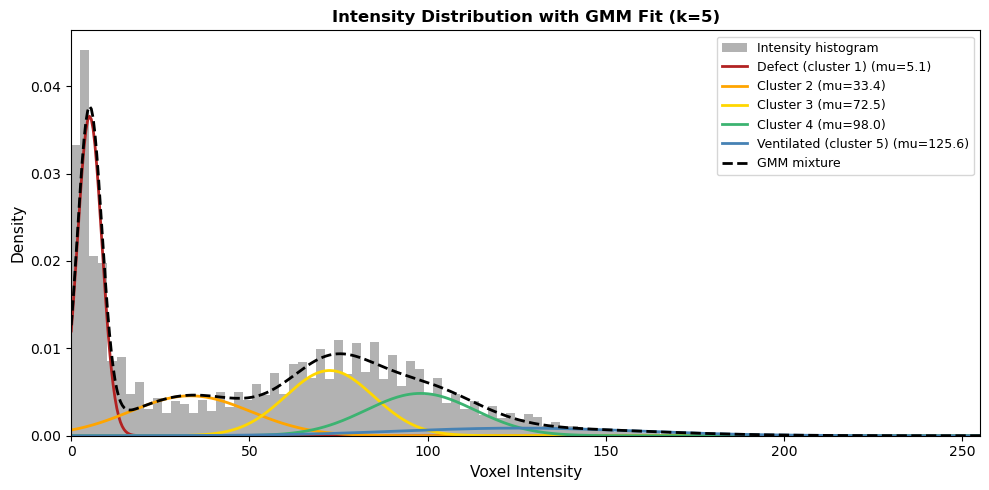


GMM component summary (sorted by mean intensity):
Cluster          Weight       Mean        Std
Defect           0.316       5.1       3.4
Cluster 2        0.194      33.4      16.9
Cluster 3        0.231      72.5      12.4
Cluster 4        0.185      98.0      15.3
Cluster 5        0.074     125.6      33.8


In [100]:
from scipy.stats import norm

voxels_hist = xe_raw[mask_no_t].astype(float)

# fit GMM with k=5
gmm = GaussianMixture(n_components=5, n_init=5, random_state=42)
gmm.fit(voxels_hist.reshape(-1, 1))

# sort components by mean (defect = lowest)
order = np.argsort(gmm.means_.flatten())
means_gmm = gmm.means_.flatten()[order]
stds_gmm = np.sqrt(gmm.covariances_.flatten())[order]
weights_gmm = gmm.weights_[order]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(voxels_hist, bins=100, density=True, alpha=0.6, color='gray', label='Intensity histogram')

x_range = np.linspace(0, 255, 500)
colors = ['firebrick', 'orange', 'gold', 'mediumseagreen', 'steelblue']
labels_gmm = ['Defect (cluster 1)', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Ventilated (cluster 5)']

total = np.zeros_like(x_range)
for i in range(5):
    component = weights_gmm[i] * norm.pdf(x_range, means_gmm[i], stds_gmm[i])
    total += component
    ax.plot(x_range, component, color=colors[i], lw=2, label=f'{labels_gmm[i]} (mu={means_gmm[i]:.1f})')

ax.plot(x_range, total, 'k--', lw=2, label='GMM mixture')
ax.set_xlabel('Voxel Intensity', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('Intensity Distribution with GMM Fit (k=5)', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(0, 255)
plt.tight_layout()
plt.savefig('fig_supp_gmm_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nGMM component summary (sorted by mean intensity):")
print(f"{'Cluster':<12} {'Weight':>10} {'Mean':>10} {'Std':>10}")
for i in range(5):
    print(f"{'Defect' if i == 0 else f'Cluster {i+1}':<12} "
          f"{weights_gmm[i]:>9.3f} {means_gmm[i]:>9.1f} {stds_gmm[i]:>9.1f}")

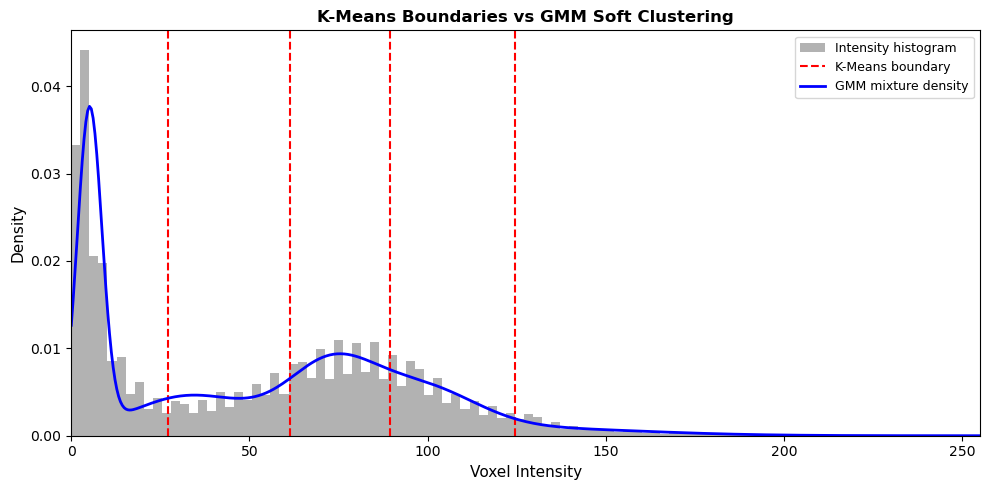

K-Means cluster boundaries: ['27.2', '61.4', '89.5', '124.6']
GMM uses soft probabilistic assignment - no hard boundaries.


In [101]:
# K-Means boundaries for comparison
km = KMeans(n_clusters=5, n_init=10, random_state=42)
km.fit(voxels_hist.reshape(-1, 1))
km_centers = np.sort(km.cluster_centers_.flatten())
km_bounds = [(km_centers[i] + km_centers[i+1]) / 2 for i in range(4)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(voxels_hist, bins=100, density=True, alpha=0.6, color='gray', label='Intensity histogram')

for i, b in enumerate(km_bounds):
    ax.axvline(b, color='red', ls='--', lw=1.5, label='K-Means boundary' if i == 0 else None)

ax.plot(x_range, total, 'b-', lw=2, label='GMM mixture density')
ax.set_xlabel('Voxel Intensity', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('K-Means Boundaries vs GMM Soft Clustering', fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(0, 255)
plt.tight_layout()
plt.savefig('fig_supp_kmeans_vs_gmm.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"K-Means cluster boundaries: {[f'{b:.1f}' for b in km_bounds]}")
print("GMM uses soft probabilistic assignment - no hard boundaries.")

### S5: Single-Method Bootstrap (Hierarchical Complete)

Bootstrap distribution for Hierarchical Complete at k=5. The 2×2 panel in Experiment 3 is the primary reference; this supplements it with a larger single-panel view for HC.

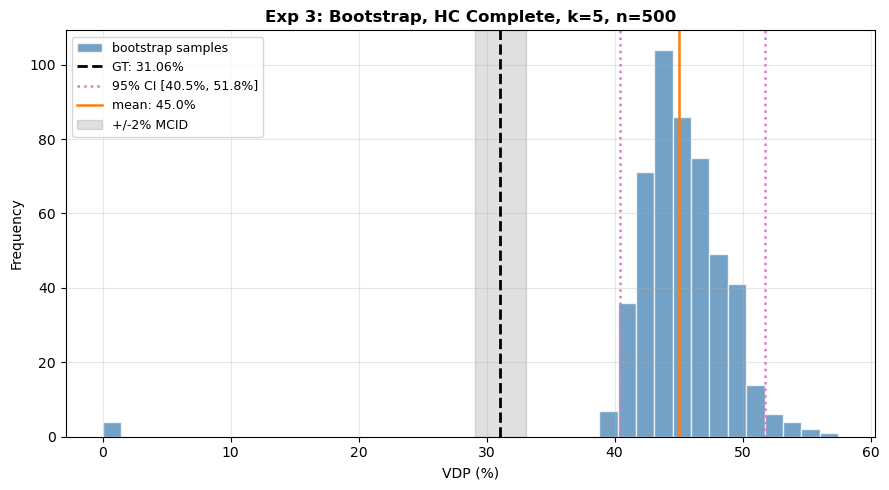

In [102]:
# fig 3
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(boot_vdps, bins=40, color='steelblue', alpha=0.75, edgecolor='white', label='bootstrap samples')
ax.axvline(GT_VDP, color='black', ls='--', lw=2, label=f'GT: {GT_VDP:.2f}%')
ax.axvline(ci_low, color='tab:pink', ls=':', lw=1.8, label=f'95% CI [{ci_low:.1f}%, {ci_high:.1f}%]')
ax.axvline(ci_high, color='tab:pink', ls=':', lw=1.8)
ax.axvline(boot_vdps.mean(), color='tab:orange', ls='-', lw=1.8, label=f'mean: {boot_vdps.mean():.1f}%')
ax.axvspan(GT_VDP-2, GT_VDP+2, alpha=0.12, color='black', label='+/-2% MCID')
ax.set_xlabel('VDP (%)')
ax.set_ylabel('Frequency')
ax.set_title(f'Exp 3: Bootstrap, HC Complete, k=5, n={N_BOOT}', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('fig3_bootstrap.png', dpi=150, bbox_inches='tight')
plt.show()

### S6: Supplementary Summary

In [103]:
print('Supplementary Results Summary')

print(f"\n1. Timing (fastest to slowest at k=5):")
sorted_timing = sorted(timing_results.items(), key=lambda x: x[1][0])
for method, (mean_t, _) in sorted_timing:
    name = dict(zip(methods, method_names))[method]
    print(f"   {name:<28} {mean_t:>8.2f} ms")

best_lr_idx = np.argmin([r[4] for r in lr_hp_results])
print(f"\n2. Best LR regularization: C={lr_hp_results[best_lr_idx][0]}")
print(f"   VDP={lr_hp_results[best_lr_idx][3]:.2f}%, |err|={lr_hp_results[best_lr_idx][4]:.2f}%")

best_mlp_idx = np.argmin([r[4] for r in mlp_hp_results])
print(f"\n3. Best MLP architecture: {mlp_hp_results[best_mlp_idx][0]}")
print(f"   VDP={mlp_hp_results[best_mlp_idx][3]:.2f}%, |err|={mlp_hp_results[best_mlp_idx][4]:.2f}%")

print(f"\n4. PyTorch vs sklearn MLP:")
print(f"   PyTorch VDP: {VDP_PT:.2f}%")
print(f"   sklearn VDP: {VDP_MLP:.2f}%")
print(f"   Difference:  {abs(VDP_PT - VDP_MLP):.2f}%")

print(f"\n5. GMM component summary:")
print(f"   Means: {[f'{m:.1f}' for m in means_gmm]}")
print(f"   Defect cluster weight: {100*weights_gmm[0]:.1f}% of voxels")

Supplementary Results Summary

1. Timing (fastest to slowest at k=5):
   K-Means                         45.48 ms
   Hierarchical (Complete)         74.46 ms
   Hierarchical (Ward)             79.24 ms
   GMM                            429.14 ms

2. Best LR regularization: C=100.0
   VDP=8.76%, |err|=22.30%

3. Best MLP architecture: (32, 16)
   VDP=25.34%, |err|=5.71%

4. PyTorch vs sklearn MLP:
   PyTorch VDP: 20.77%
   sklearn VDP: 20.50%
   Difference:  0.28%

5. GMM component summary:
   Means: ['5.1', '33.4', '72.5', '98.0', '125.6']
   Defect cluster weight: 31.6% of voxels
